In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
#Load datasets with proper encoding handling

users = pd.read_csv('Users.csv', encoding='latin-1')  # Changed encoding to handle special characters
books = pd.read_csv('Books.csv', encoding='latin-1')  # Changed encoding to handle special characters
ratings = pd.read_csv('Ratings.csv', encoding='latin-1')  # Changed encoding to handle special characters

C:\Users\sahit\AppData\Local\Temp\ipykernel_19108\3804726325.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv', encoding='latin-1')  # Changed encoding to handle special characters


In [3]:
users

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN
...,...,...,...
278853,278854,"portland, oregon, usa",NaN
278854,278855,"tacoma, washington, united kingdom",50.0
278855,278856,"brampton, ontario, canada",NaN
278856,278857,"knoxville, tennessee, usa",NaN


In [4]:
books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [5]:
ratings

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [6]:
# Get dataset info
users.info()
books.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)


In [7]:
print(books.shape)
print(users.shape)
print(ratings.shape)

books.head()
users.head()
ratings.head()

(271360, 8)
(278858, 3)
(1149780, 3)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
print(books.isnull().sum())
print(users.isnull().sum())
print(ratings.isnull().sum())

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64
User-ID          0
Location         0
Age         110762
dtype: int64
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [9]:
print("Books:", books.duplicated().sum())
print("Users:", users.duplicated().sum())
print("Ratings:", ratings.duplicated().sum())

Books: 0
Users: 0
Ratings: 0


In [10]:
users.drop(columns=['Age'], inplace=True)

In [11]:
books['Book-Author'] = books['Book-Author'].fillna('Unknown')
books['Publisher'] = books['Publisher'].fillna('Unknown')

In [12]:
books['Image-URL-L'] = books['Image-URL-L'].fillna('Not Available')

In [13]:
#---------checking the null values------------#

In [14]:
print(books.isnull().sum())
print(users.isnull().sum())
print(ratings.isnull().sum())

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64
User-ID     0
Location    0
dtype: int64
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [15]:
#-----------Merge Ratings and Books-----------#
ratings_with_name = ratings.merge(
    books,
    on='ISBN'
)

#--------------Count Number of Ratings per Book------------#
num_rating_df = ratings_with_name.groupby(
    'Book-Title'
).count()['Book-Rating'].reset_index()

#---------Rename Column---------3
num_rating_df.rename(
    columns={'Book-Rating':'num_ratings'},
    inplace=True
)

#------------Calculate Average Rating----------#
avg_rating_df = ratings_with_name.groupby(
    'Book-Title'
)['Book-Rating'].mean().reset_index()

#---------Rename Column-------------#
avg_rating_df.rename(
    columns={'Book-Rating':'avg_rating'},
    inplace=True
)

#-------Merge Both Results--------#
popular_df = num_rating_df.merge(
    avg_rating_df,
    on='Book-Title'
)

#---------Keep Only Popular Books--------#
popular_df = popular_df[
    popular_df['num_ratings'] >= 250
]

#--------------Sort by Average Rating--------#
popular_df = popular_df.sort_values(
    'avg_rating',
    ascending=False
)
#--------Display 10 books-----------#
popular_df.head(10)

,Book-Title,num_ratings,avg_rating
80434,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
80422,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
80441,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
80426,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
80414,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453
191612,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117
187377,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370
80445,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652
211384,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769
219741,To Kill a Mockingbird,510,4.700000


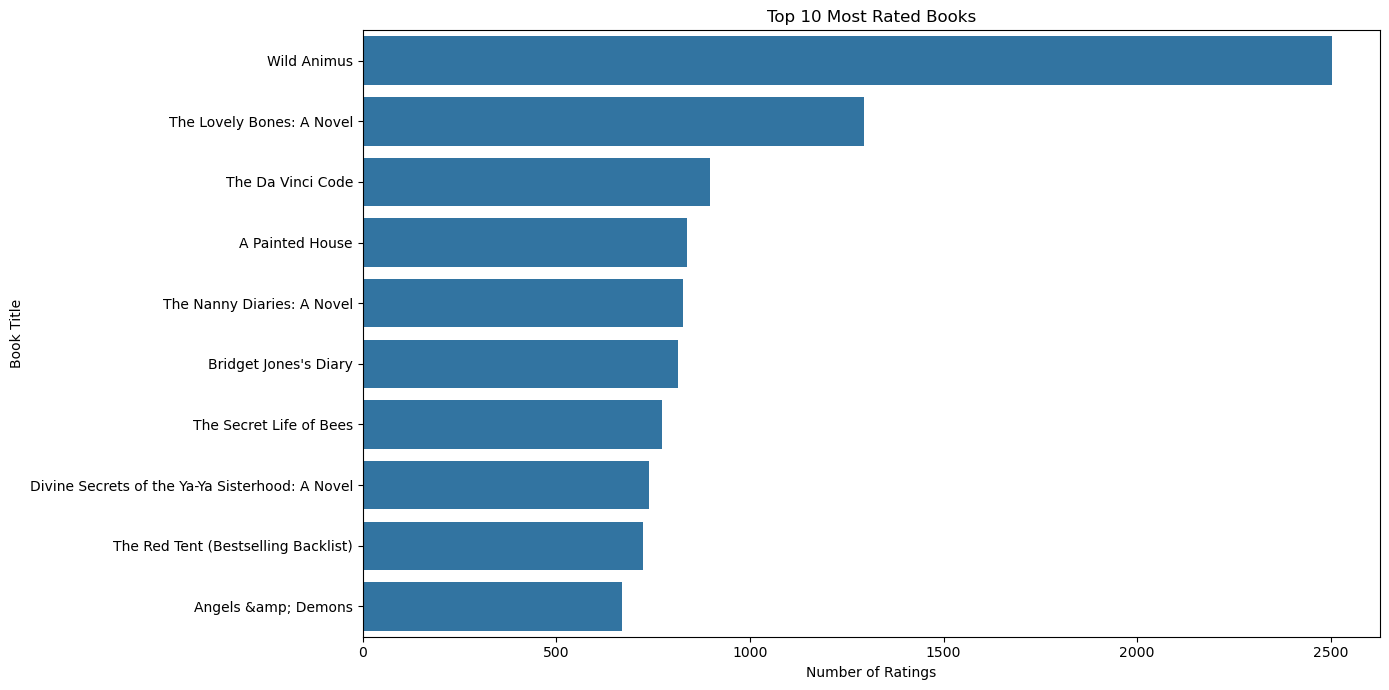

In [16]:
# Top 10 Most Rated Books

top_books = num_rating_df.sort_values(
    by='num_ratings',
    ascending=False
).head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    data=top_books,
    x='num_ratings',
    y='Book-Title'
)

plt.title('Top 10 Most Rated Books')
plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')

plt.tight_layout()
plt.show()

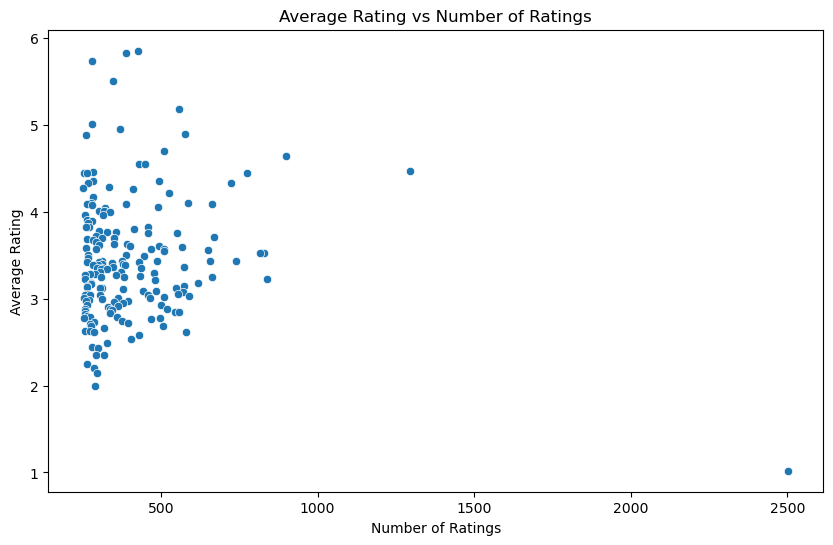

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=popular_df,
    x='num_ratings',
    y='avg_rating'
)

plt.title('Average Rating vs Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.show()

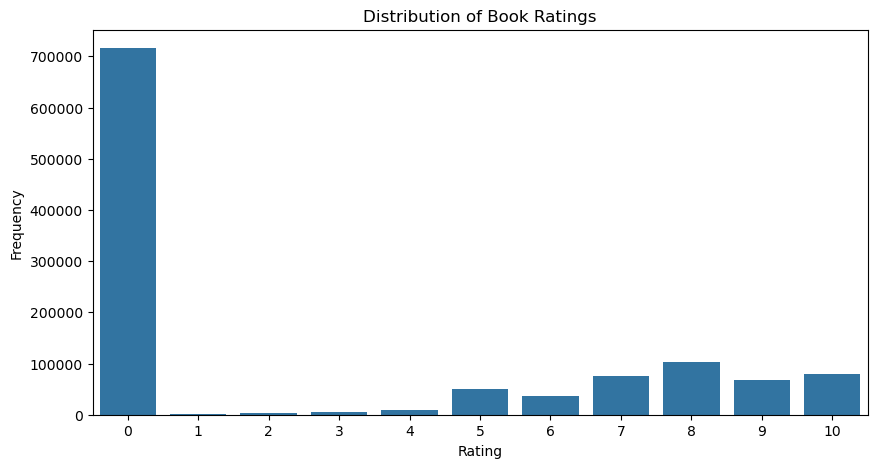

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Book-Rating',
    data=ratings
)

plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

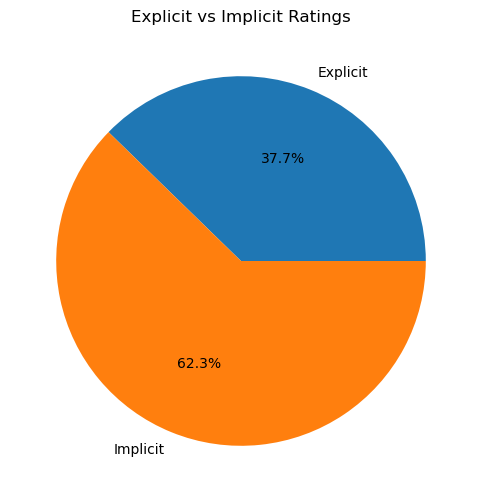

In [19]:
rating_types = pd.DataFrame({
    'Type':['Explicit','Implicit'],
    'Count':[
        ratings[ratings['Book-Rating'] > 0].shape[0],
        ratings[ratings['Book-Rating'] == 0].shape[0]
    ]
})

plt.figure(figsize=(6,6))

plt.pie(
    rating_types['Count'],
    labels=rating_types['Type'],
    autopct='%1.1f%%'
)

plt.title('Explicit vs Implicit Ratings')
plt.show()

In [20]:
# Drop rows with duplicate book title
new_books = books.drop_duplicates('Book-Title')

In [21]:
# Merge ratings and new_books df
ratings_with_name = ratings.merge(new_books, on='ISBN')

# Drop non-relevant columns
ratings_with_name.drop(['ISBN', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis = 1, inplace = True)

In [22]:
# Merge new 'ratings_with_name' df with users df
users_ratings_matrix = ratings_with_name.merge(users, on='User-ID')

# Drop non-relevant columns
users_ratings_matrix.drop(['Location'], axis = 1, inplace = True)

# Print the first few rows of the new dataframe
users_ratings_matrix.head()

,User-ID,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276725,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
1,276729,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press
2,276729,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press
3,276746,0,Lightning,Dean R. Koontz,1996,Berkley Publishing Group
4,276746,0,Manhattan Hunt Club,JOHN SAUL,2002,Ballantine Books


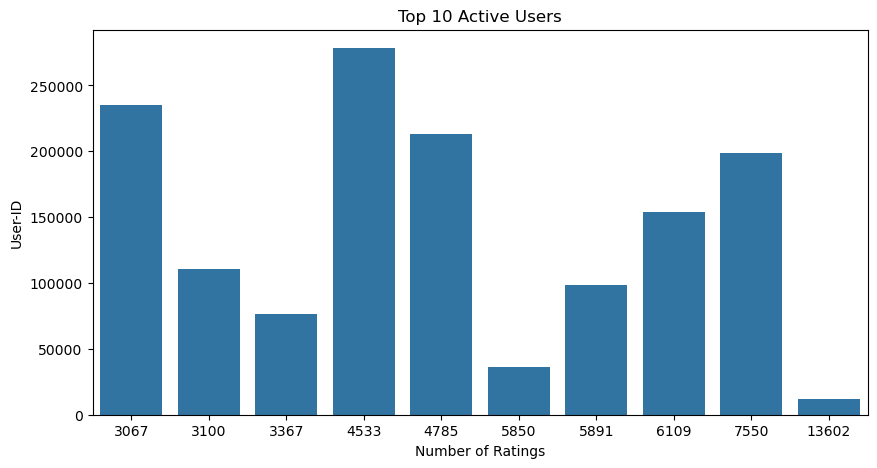

In [23]:
top_users = ratings.groupby(
    'User-ID'
)['Book-Rating'].count().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_users.values,
    y=top_users.index
)

plt.title('Top 10 Active Users')
plt.xlabel('Number of Ratings')
plt.show()

In [24]:
# Filter down 'users_ratings_matrix' on the basis of users who gave many book ratings
x = users_ratings_matrix.groupby('User-ID').count()['Book-Rating'] > 100
knowledgeable_users = x[x].index
filtered_users_ratings = users_ratings_matrix[users_ratings_matrix['User-ID'].isin(knowledgeable_users)]

# Filter down 'users_ratings_matrix' on the basis of books with most ratings
y = filtered_users_ratings.groupby('Book-Title').count()['Book-Rating'] >= 50
famous_books = y[y].index
final_users_ratings = filtered_users_ratings[filtered_users_ratings['Book-Title'].isin(famous_books)]

In [25]:
# Pivot table creation
pivot_table = final_users_ratings.pivot_table(index = 'Book-Title', columns = 'User-ID', values = 'Book-Rating')

# Filling the NA values with '0'
pivot_table.fillna(0, inplace = True)
pivot_table.head()

User-ID,254,507,882,1424,1435,1733,1903,2033,2110,2276,...,274808,275020,275970,276680,277427,277478,277639,278137,278188,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
from sklearn.preprocessing import StandardScaler
# Standardize the pivot table
scaler = StandardScaler(with_mean=True, with_std=True)
pivot_table_normalized = scaler.fit_transform(pivot_table)

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
# Calculate the similarity matrix for all the books
similarity_score = cosine_similarity(pivot_table_normalized)

In [28]:
#------Function Definition-----------#
def recommend_cosine(book_name, n=5):
#-Find the Index of the Input Book-----#
    
    index = np.where(pivot_table.index == book_name)[0][0]
#------Get Similar Books------------#
    similar_books = sorted(
        list(enumerate(similarity_score[index])),
        key=lambda x: x[1],
        reverse=True
    )[1:n+1]

 #---------Create Empty List--------#
    data = []
#----------Loop Through Similar Books----------#
    for idx, similarity in similar_books:
#---------Fetch Book Details-----------#
        temp_df = new_books[
            new_books['Book-Title'] == pivot_table.index[idx]
        ]
#----------Create a Recommendation Item--------#
        item = []

        item.extend(temp_df['Book-Title'].values)
        item.extend(temp_df['Book-Author'].values)
        item.extend(temp_df['Image-URL-M'].values)

        data.append(item)

    return data

In [29]:
#similarity score 
def cosine_avg_score(book_name,n=5):

    idx = np.where(
        pivot_table.index == book_name
    )[0][0]

    similar_books = sorted(
        list(enumerate(similarity_score[idx])),
        key=lambda x:x[1],
        reverse=True
    )[1:n+1]

    return np.mean([x[1] for x in similar_books])

In [30]:
recommend_cosine("The Da Vinci Code", 10)

[['Angels &amp; Demons',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg'],
 ["River's End",
  'Nora Roberts',
  'http://images.amazon.com/images/P/0515127833.01.MZZZZZZZ.jpg'],
 ['The Blue Nowhere : A Novel',
  'Jeffery Deaver',
  'http://images.amazon.com/images/P/0671042262.01.MZZZZZZZ.jpg'],
 ['The Lovely Bones: A Novel',
  'Alice Sebold',
  'http://images.amazon.com/images/P/0316666343.01.MZZZZZZZ.jpg'],
 ["East of Eden (Oprah's Book Club)",
  'John Steinbeck',
  'http://images.amazon.com/images/P/0142004235.01.MZZZZZZZ.jpg'],
 ['The Alienist',
  'Caleb Carr',
  'http://images.amazon.com/images/P/0553572997.01.MZZZZZZZ.jpg'],
 ['Balzac and the Little Chinese Seamstress : A Novel',
  'DAI SIJIE',
  'http://images.amazon.com/images/P/0385722206.01.MZZZZZZZ.jpg'],
 ['Middlesex: A Novel',
  'Jeffrey Eugenides',
  'http://images.amazon.com/images/P/0312422156.01.MZZZZZZZ.jpg'],
 ['Touching Evil',
  'Kay Hooper',
  'http://images.amazon.com/images/P/055358

In [31]:
print("The Da Vinci Code" in pivot_table.index)

True


In [32]:
recommend_cosine("Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))", 5)

[['Harry Potter and the Chamber of Secrets (Book 2)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/0439064872.01.MZZZZZZZ.jpg'],
 ['Harry Potter and the Goblet of Fire (Book 4)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/0439139597.01.MZZZZZZZ.jpg'],
 ['Harry Potter and the Order of the Phoenix (Book 5)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/043935806X.01.MZZZZZZZ.jpg'],
 ['Harry Potter and the Prisoner of Azkaban (Book 3)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'],
 ['Girl, Interrupted',
  'SUSANNA KAYSEN',
  'http://images.amazon.com/images/P/0679746048.01.MZZZZZZZ.jpg']]

In [33]:
author_name = "J. K. Rowling"

new_books[new_books['Book-Author'] == author_name][
    ['Book-Title', 'Book-Author']
].drop_duplicates()

,Book-Title,Book-Author
2143,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling
2809,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling
3459,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling
3839,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling
3914,Quidditch Through the Ages,J. K. Rowling
...,...,...
213701,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling
234605,Harry Potter and the Sorcerer's Stone,J. K. Rowling
234611,Harry Potter and the Sorcerer's Stone: A Delux...,J. K. Rowling
251233,Harry Potter y El Caliz de Fuego,J. K. Rowling


In [34]:
author_pivot = final_users_ratings.pivot_table(
    index='Book-Author',
    columns='User-ID',
    values='Book-Rating'
)

author_pivot.fillna(0, inplace=True)

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

scaler = StandardScaler()

author_pivot_scaled = scaler.fit_transform(author_pivot)

author_similarity = cosine_similarity(author_pivot_scaled)

In [36]:
def recommend_books_by_author(author_name, n=5):

    author_books = new_books[
        new_books['Book-Author'].str.lower() == author_name.lower()
    ]['Book-Title'].unique()

    if len(author_books) == 0:
        return f"No books found for author: {author_name}"

    recommendations = []

    for book in author_books[:3]:

        if book in pivot_table.index:

            index = np.where(pivot_table.index == book)[0][0]

            similar_books = sorted(
                list(enumerate(similarity_score[index])),
                key=lambda x: x[1],
                reverse=True
            )[1:n+1]

            for idx, score in similar_books:

                temp_df = new_books[
                    new_books['Book-Title'] == pivot_table.index[idx]
                ]

                title = temp_df['Book-Title'].values[0]
                author = temp_df['Book-Author'].values[0]
                image_url = temp_df['Image-URL-M'].values[0]

                recommendations.append(
                    (title, author, image_url)
                )

    # Remove duplicates
    recommendations = list(dict.fromkeys(recommendations))

    return recommendations[:n]

In [37]:
recommend_books_by_author("J. K. Rowling", 10)

[('Harry Potter and the Chamber of Secrets (Book 2)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/0439064872.01.MZZZZZZZ.jpg'),
 ('Harry Potter and the Goblet of Fire (Book 4)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/0439139597.01.MZZZZZZZ.jpg'),
 ('Harry Potter and the Order of the Phoenix (Book 5)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/043935806X.01.MZZZZZZZ.jpg'),
 ('Harry Potter and the Prisoner of Azkaban (Book 3)',
  'J. K. Rowling',
  'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'),
 ('Girl, Interrupted',
  'SUSANNA KAYSEN',
  'http://images.amazon.com/images/P/0679746048.01.MZZZZZZZ.jpg'),
 ('A Walk to Remember',
  'Nicholas Sparks',
  'http://images.amazon.com/images/P/0446608955.01.MZZZZZZZ.jpg'),
 ('Like Water for Chocolate: A Novel in Monthly Installments With Recipes, Romances and Home Remedies',
  'Laura Esquivel',
  'http://images.amazon.com/images/P/0385474016.01.MZZZZZZZ.jpg'),
 ('Anne of Green Gables (Ann

In [38]:
#-------------KNN Recommendation-

In [39]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn_model.fit(pivot_table)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [40]:
def recommend_knn(book_name, n=5):

    if book_name not in pivot_table.index:
        return "Book not found"

    book_idx = np.where(
        pivot_table.index == book_name
    )[0][0]

    distances, indices = knn_model.kneighbors(
        pivot_table.iloc[book_idx, :].values.reshape(1, -1),
        n_neighbors=n+1
    )

    recommendations = []

    for i in range(1, len(indices.flatten())):

        recommended_book = pivot_table.index[
            indices.flatten()[i]
        ]

        temp_df = new_books[
            new_books['Book-Title'] == recommended_book
        ]

        item = []

        item.append(temp_df['Book-Title'].values[0])
        item.append(temp_df['Book-Author'].values[0])
        item.append(temp_df['Image-URL-M'].values[0])

        recommendations.append(item)

    return recommendations

In [41]:
def knn_avg_score(book_name,n=5):

    idx = np.where(
        pivot_table.index == book_name
    )[0][0]

    distances,indices = knn_model.kneighbors(
        pivot_table.iloc[idx,:].values.reshape(1,-1),
        n_neighbors=n+1
    )

    similarities = 1 - distances.flatten()[1:]

    return np.mean(similarities)

In [42]:
recommend_knn("The Da Vinci Code", 5)

[['Angels &amp; Demons',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg'],
 ['Touching Evil',
  'Kay Hooper',
  'http://images.amazon.com/images/P/0553583441.01.MZZZZZZZ.jpg'],
 ['The Blue Nowhere : A Novel',
  'Jeffery Deaver',
  'http://images.amazon.com/images/P/0671042262.01.MZZZZZZZ.jpg'],
 ['TickTock',
  'Dean R. Koontz',
  'http://images.amazon.com/images/P/034538430X.01.MZZZZZZZ.jpg'],
 ["East of Eden (Oprah's Book Club)",
  'John Steinbeck',
  'http://images.amazon.com/images/P/0142004235.01.MZZZZZZZ.jpg']]

In [43]:
#----------SVD Recommendation-----------#

In [44]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

book_features = svd.fit_transform(pivot_table)

svd_similarity = cosine_similarity(book_features)

In [45]:
print(svd_similarity.shape)

(620, 620)


In [46]:
def recommend_svd(book_name, n=5):

    if book_name not in pivot_table.index:
        return "Book not found"

    idx = np.where(
        pivot_table.index == book_name
    )[0][0]

    similar_books = sorted(
        list(enumerate(svd_similarity[idx])),
        key=lambda x: x[1],
        reverse=True
    )[1:n+1]

    recommendations = []

    for i in similar_books:

        recommended_book = pivot_table.index[i[0]]

        temp_df = new_books[
            new_books['Book-Title'] == recommended_book
        ]
        

        item = []

        item.append(temp_df['Book-Title'].values[0])
        item.append(temp_df['Book-Author'].values[0])
        item.append(temp_df['Image-URL-M'].values[0])

        recommendations.append(item)

    return recommendations

In [47]:
def svd_avg_score(book_name,n=5):

    idx = np.where(
        pivot_table.index == book_name
    )[0][0]

    similar_books = sorted(
        list(enumerate(svd_similarity[idx])),
        key=lambda x:x[1],
        reverse=True
    )[1:n+1]

    return np.mean([x[1] for x in similar_books])

In [48]:
recommend_svd("The Da Vinci Code", 5)

[['Touching Evil',
  'Kay Hooper',
  'http://images.amazon.com/images/P/0553583441.01.MZZZZZZZ.jpg'],
 ["East of Eden (Oprah's Book Club)",
  'John Steinbeck',
  'http://images.amazon.com/images/P/0142004235.01.MZZZZZZZ.jpg'],
 ['TickTock',
  'Dean R. Koontz',
  'http://images.amazon.com/images/P/034538430X.01.MZZZZZZZ.jpg'],
 ['The Blue Nowhere : A Novel',
  'Jeffery Deaver',
  'http://images.amazon.com/images/P/0671042262.01.MZZZZZZZ.jpg'],
 ['Pay It Forward',
  'Catherine Ryan Hyde',
  'http://images.amazon.com/images/P/0743412028.01.MZZZZZZZ.jpg']]

In [49]:
book = "The Da Vinci Code"

print("Cosine Similarity")
print(recommend_cosine(book))

print("\nKNN")
print(recommend_knn(book))

print("\nSVD")
print(recommend_svd(book))

Cosine Similarity
[['Angels &amp; Demons', 'Dan Brown', 'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg'], ["River's End", 'Nora Roberts', 'http://images.amazon.com/images/P/0515127833.01.MZZZZZZZ.jpg'], ['The Blue Nowhere : A Novel', 'Jeffery Deaver', 'http://images.amazon.com/images/P/0671042262.01.MZZZZZZZ.jpg'], ['The Lovely Bones: A Novel', 'Alice Sebold', 'http://images.amazon.com/images/P/0316666343.01.MZZZZZZZ.jpg'], ["East of Eden (Oprah's Book Club)", 'John Steinbeck', 'http://images.amazon.com/images/P/0142004235.01.MZZZZZZZ.jpg']]

KNN
[['Angels &amp; Demons', 'Dan Brown', 'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg'], ['Touching Evil', 'Kay Hooper', 'http://images.amazon.com/images/P/0553583441.01.MZZZZZZZ.jpg'], ['The Blue Nowhere : A Novel', 'Jeffery Deaver', 'http://images.amazon.com/images/P/0671042262.01.MZZZZZZZ.jpg'], ['TickTock', 'Dean R. Koontz', 'http://images.amazon.com/images/P/034538430X.01.MZZZZZZZ.jpg'], ["East of Eden (Oprah'

In [50]:
#content based filtering (TF - IDF +cosine)

In [51]:
content_books = new_books[
    new_books['Book-Title'].isin(pivot_table.index)
].copy()

content_books.reset_index(
    drop=True,
    inplace=True
)

In [52]:
content_books['features'] = (
    content_books['Book-Title'].fillna('') + ' ' +
    content_books['Book-Author'].fillna('') + ' ' +
    content_books['Publisher'].fillna('') + ' ' +
    content_books['Year-Of-Publication'].astype(str)
)

content_books[['Book-Title','features']].head()

,Book-Title,features
0,The Testament,The Testament John Grisham Dell 1999
1,Beloved (Plume Contemporary Fiction),Beloved (Plume Contemporary Fiction) Toni Morr...
2,Wild Animus,Wild Animus Rich Shapero Too Far 2004
3,Airframe,Airframe Michael Crichton Ballantine Books 1997
4,Timeline,Timeline MICHAEL CRICHTON Ballantine Books 2000


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    content_books['features']
)

print(tfidf_matrix.shape)

(620, 1604)


In [54]:
from sklearn.metrics.pairwise import cosine_similarity

content_similarity = cosine_similarity(
    tfidf_matrix
)

print(content_similarity.shape)

(620, 620)


In [55]:
def recommend_content(book_name, n=5):

    if book_name not in content_books['Book-Title'].values:
        return "Book not found"

    idx = content_books[
        content_books['Book-Title'] == book_name
    ].index[0]

    similar_books = sorted(
        list(enumerate(content_similarity[idx])),
        key=lambda x: x[1],
        reverse=True
    )[1:n+1]

    recommendations = []

    for i in similar_books:

        recommended_book = content_books.iloc[i[0]]['Book-Title']

        temp_df = content_books[
            content_books['Book-Title'] == recommended_book
        ]

        item = []

        item.append(temp_df['Book-Title'].values[0])
        item.append(temp_df['Book-Author'].values[0])
        item.append(temp_df['Image-URL-M'].values[0])

        recommendations.append(item)

    return recommendations

In [56]:
recommend_content(
    "The Da Vinci Code",
    5
)

[['Deception Point',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027387.01.MZZZZZZZ.jpg'],
 ['Digital Fortress : A Thriller',
  'Dan Brown',
  'http://images.amazon.com/images/P/0312995423.01.MZZZZZZZ.jpg'],
 ['Angels &amp; Demons',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg'],
 ['Bleachers',
  'John Grisham',
  'http://images.amazon.com/images/P/0385511612.01.MZZZZZZZ.jpg'],
 ['The Genesis Code',
  'John Case',
  'http://images.amazon.com/images/P/0345422317.01.MZZZZZZZ.jpg']]

In [57]:
def content_avg_score(book_name,n=5):

    idx = content_books[
        content_books['Book-Title']==book_name
    ].index[0]

    similarity_scores = sorted(
        list(enumerate(content_similarity[idx])),
        key=lambda x:x[1],
        reverse=True
    )[1:n+1]

    return np.mean(
        [x[1] for x in similarity_scores]
    )

In [58]:
book = np.random.choice(
    pivot_table.index
)

cosine_score = cosine_avg_score(book)

knn_score = knn_avg_score(book)

svd_score = svd_avg_score(book)

content_score = content_avg_score(book)

comparison = pd.DataFrame({

    'Model':[
        'Cosine',
        'KNN',
        'SVD',
        'Content-Based'
    ],

    'Average Similarity Score':[

        cosine_score,
        knn_score,
        svd_score,
        content_score
    ]
})

print(comparison)

           Model  Average Similarity Score
0         Cosine                  0.133768
1            KNN                  0.215513
2            SVD                  0.567351
3  Content-Based                  0.362084


In [59]:
best_model = comparison.loc[
    comparison[
        'Average Similarity Score'
    ].idxmax()
]

print(
    "Best Model:",
    best_model['Model']
)

print(
    "Score:",
    round(
        best_model[
            'Average Similarity Score'
        ],
        4
    )
)

Best Model: SVD
Score: 0.5674


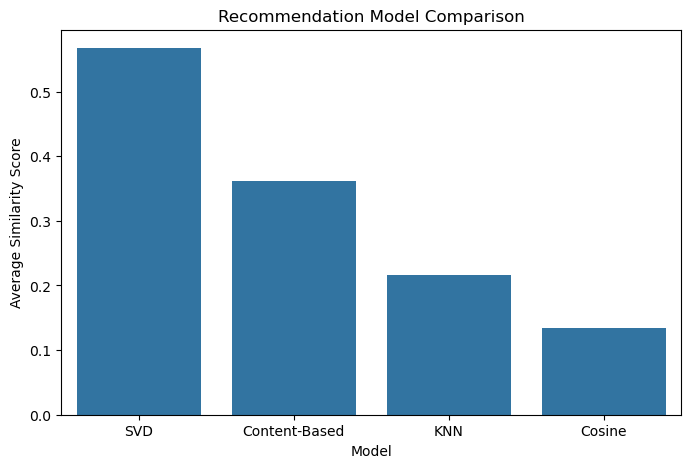

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison.sort_values(
        'Average Similarity Score',
        ascending=False
    ),
    x='Model',
    y='Average Similarity Score'
)

plt.title('Recommendation Model Comparison')
plt.ylabel('Average Similarity Score')
plt.show()

In [61]:
# Hybrid reccommendation

In [62]:
def recommend_hybrid(book_name, n=5,
                     svd_weight=0.7,
                     content_weight=0.3):

    if book_name not in pivot_table.index:
        return "Book not found"

    # SVD Index
    svd_idx = np.where(
        pivot_table.index == book_name
    )[0][0]

    # Content Index
    content_idx = content_books[
        content_books['Book-Title'] == book_name
    ].index[0]

    hybrid_scores = []

    for i in range(len(content_books)):

        book_title = content_books.iloc[i]['Book-Title']

        # Skip books not present in SVD matrix
        if book_title not in pivot_table.index:
            continue

        svd_book_idx = np.where(
            pivot_table.index == book_title
        )[0][0]

        svd_score = svd_similarity[
            svd_idx,
            svd_book_idx
        ]

        content_score = content_similarity[
            content_idx,
            i
        ]

        final_score = (
            svd_weight * svd_score
            +
            content_weight * content_score
        )

        hybrid_scores.append(
            (
                book_title,
                final_score
            )
        )

    hybrid_scores = sorted(
        hybrid_scores,
        key=lambda x: x[1],
        reverse=True
    )

    hybrid_scores = hybrid_scores[1:n+1]

    recommendations = []

    for title, score in hybrid_scores:

        temp_df = content_books[
            content_books['Book-Title'] == title
        ]

        item = []

        item.append(
            temp_df['Book-Title'].values[0]
        )

        item.append(
            temp_df['Book-Author'].values[0]
        )

        item.append(
            temp_df['Image-URL-M'].values[0]
        )

        item.append(
            round(score,4)
        )

        recommendations.append(item)

    return recommendations

In [63]:
recommend_hybrid(
    "The Da Vinci Code",
    5
)

[['Deception Point',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027387.01.MZZZZZZZ.jpg',
  np.float64(0.3499)],
 ['Angels &amp; Demons',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg',
  np.float64(0.3415)],
 ["East of Eden (Oprah's Book Club)",
  'John Steinbeck',
  'http://images.amazon.com/images/P/0142004235.01.MZZZZZZZ.jpg',
  np.float64(0.3201)],
 ['Touching Evil',
  'Kay Hooper',
  'http://images.amazon.com/images/P/0553583441.01.MZZZZZZZ.jpg',
  np.float64(0.3196)],
 ['The Jester',
  'James Patterson',
  'http://images.amazon.com/images/P/0316602051.01.MZZZZZZZ.jpg',
  np.float64(0.3061)]]

In [64]:
def hybrid_avg_score(book_name, n=5):

    recommendations = recommend_hybrid(
        book_name,
        n
    )

    scores = [
        item[3]
        for item in recommendations
    ]

    return np.mean(scores)

In [65]:
book = np.random.choice(
    pivot_table.index
)

comparison = pd.DataFrame({

    'Model':[
        'Cosine',
        'KNN',
        'SVD',
        'Content-Based',
        'Hybrid'
    ],

    'Average Similarity Score':[

        cosine_avg_score(book),
        knn_avg_score(book),
        svd_avg_score(book),
        content_avg_score(book),
        hybrid_avg_score(book)

    ]
})

print(comparison)

           Model  Average Similarity Score
0         Cosine                  0.154870
1            KNN                  0.244886
2            SVD                  0.661238
3  Content-Based                  0.374844
4         Hybrid                  0.488700


In [68]:
new_books['Amazon_Link'] = (
    "https://www.amazon.in/s?k=" +
    new_books['Book-Title'].str.replace(" ", "+")
)

C:\Users\sahit\AppData\Local\Temp\ipykernel_19108\29052487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_books['Amazon_Link'] = (


In [69]:
import pickle
pickle.dump(
    new_books,
    open('books.pkl', 'wb')
)

print("books.pkl saved successfully")

books.pkl saved successfully


In [70]:
pickle.dump(
    pivot_table,
    open('pivot_table.pkl', 'wb')
)

print("pivot_table.pkl saved successfully")

pivot_table.pkl saved successfully


In [71]:
pickle.dump(
    svd_similarity,
    open('svd_similarity.pkl', 'wb')
)

print("svd_similarity.pkl saved successfully")

svd_similarity.pkl saved successfully
